# Metody zespołowe

<div style="text-align: center;"><img src=".//Images//Ensemble_Methods.png" alt="Metody zespołowe" width="400" height="120" style="margin: 10px; "/></div>

W uczeniu maszynowym **metody zespołowe** (*ensemble methods*) to techniki polegające na łączeniu wielu modeli bazowych w celu poprawy dokładności predykcji i zwiększenia odporności na nadmierne dopasowanie (*overfitting*). Zasadniczo zamiast polegać na jednym modelu, metody zespołowe tworzą "zespół" modeli, którego zbiorowa decyzja jest zwykle trafniejsza.

**Główne rodzaje metod zespołowych**:

## Bagging (Bootstrap Aggregating)
- Główna idea: trenowanie wielu modeli tego samego typu na różnych próbkach danych (losowanych z powtórzeniem), a następnie agregowanie wyników (np. przez głosowanie lub uśrednianie).
- **Cel:** redukcja wariancji modelu.
- **Przykład:** `Random Forest` – wiele drzew decyzyjnych trenowanych na różnych próbkach i podzbiorach cech.
- **Etapy**:
    - **Bootstrap sampling**: Wygenerowanie wielu losowych podzbiorów danych z powtórzeniami z oryginalnego zbioru danych.
    - **Trenowanie modeli**: Trenowanie modelu bazowego na każdym z tych podzbiorów.
    - **Agregacja**: Agregowanie wyników wszystkich modeli bazowych (średnia w przypadku regresji, głosowanie większościowe w przypadku klasyfikacji).

<div style="text-align: center;"><img src=".//Images//Bagging.png" alt="Bagging" width="400" height="120" style="margin: 10px; "/></div>

## Boosting
- Główna idea: trenowanie modeli sekwencyjnie, gdzie każdy kolejny model uczy się poprawiać błędy poprzedniego.
- **Cel:** redukcja błędu bias i wariancji.
- **Przykłady:**
  - `AdaBoost` – nadaje większe wagi przykładom trudnym do sklasyfikowania.
  - `Gradient Boosting` – uczy kolejne modele na podstawie gradientu funkcji straty.
  - `XGBoost`, `LightGBM`, `CatBoost` – wydajne implementacje gradient boosting, często używane w konkursach ML.
- **Etapy**:
    - **Trenowanie modeli**: Model bazowy jest trenowany na danych. Każdy kolejny model jest trenowany na danych z większymi wagami przypisanymi do błędnie sklasyfikowanych przykładów przez poprzednie modele.
    - **Aktualizacja wag**: Wagi są aktualizowane w taki sposób, aby skupić się na trudnościach przypadków.
    - **Agregacja**: Wyniki modeli bazowych są sumowane z odpowiednimi wagami.

<div style="text-align: center;"><img src=".//Images//Boosting.png" alt="Boosting" width="300" height="300" style="margin: 10px; "/></div>

> ***Dlaczego celem jest redukcja wariancji?***
> 
> Wariancja odnosi się do wrażliwości modelu na zmiany danych treningowych.
> Model o wysokiej wariancji:
> * dopasowuje się bardzo mocno do danych uczących,
> * uczy się szumów,
> * łatwo się przeucza (overfitting),
> * osiąga dobre wyniki na treningu, ale słabe na testach.
>
> ***Dlaczego celem jest redukcja bias?***
> 
> Bias (błąd systematyczny, obciążenie) to skłonność modelu do nadmiernego upraszczania rzeczywistości.
> Model o wysokim bias:
> * ignoruje złożoność danych,
> * niedoucza się (underfitting),
> * jest zbyt prosty, by uchwycić zależności,
> * popełnia duży błąd zarówno na danych treningowych, jak i testowych.
>
> Inaczej, model o wysokim bias tworzy zbyt prostą regułę – np. prosta linia dla nieliniowego problemu. Redukując bias, pozwalamy modelowi nauczyć się głębszych i bardziej złożonych zależności w danych. Wysoki bias oznacza zatem duży błąd systematyczny – model regularnie się myli w ten sam sposób.
>
> W praktyce najlepszym rozwiązaniem jest balans bias–wariancja
> Redukując bias, zwykle zwiększasz wariancję – model staje się bardziej elastyczny, ale może się przeuczyć.
> Dobry model to kompromis: **niski bias** + **umiarkowana wariancja** = **dobre uogólnienie**.

> Patrz dodatek...

---

## Stacking (Stacked Generalization)
- Główna idea: trenowanie wielu różnych modeli (np. drzewo, SVM, regresja), a następnie użycie metamodelu (np. regresji liniowej) do łączenia ich wyników.
- **Cel:** wykorzystanie komplementarnych właściwości różnych modeli.
- **Przykład:** Sklearn’s `StackingClassifier`, `mlxtend`.
- **Etapy**:
    - **Trenowanie modeli bazowych**: Kilka modeli bazowych jest trenowanych na oryginalnym zbiorze danych.
    - **Tworzenie zestawu cech**: Prognozy modeli bazowych na danych treningowych są używane jako cechy do trenowania modelu meta-uczenia.
    - **Trenowanie modelu meta-uczenia**: Model meta-uczenia jest trenowany na prognozach modeli bazowych.
    - **Agregacja**: Model meta-uczenia łączy prognozy modeli bazowych, aby uzyskać ostateczną prognozę.

## Zalety i wady

**Zalety metod zespołowych**:
- Zwiększają dokładność predykcji.
- Redukują ryzyko nadmiernego dopasowania.

**Wady**:
- Większa złożoność obliczeniowa.
- Mniejsza interpretowalność.
- Trudniejsza implementacja i strojenie hiperparametrów.

# Przykład: zbiór `breast_cancer`.

<div style="text-align: center;"><img src=".//Images//breast_cancer.jpeg" alt="breast_cancer" width="400" height="120" style="margin: 10px; "/></div>

Zbiór danych **`breast_cancer`** z biblioteki **`sklearn`** (pełna nazwa: *Breast Cancer Wisconsin (Diagnostic) Dataset*) to klasyczny, rzeczywisty zbiór danych do **binarnych zadań klasyfikacyjnych**. Jest często wykorzystywany do testowania modeli klasyfikacyjnych w uczeniu maszynowym.

---

**Podstawowe informacje**:

- **Zadanie**: klasyfikacja guzów piersi jako:
  - **0 = złośliwy (malignant)**,
  - **1 = łagodny (benign)**. </br></br>


- **Liczba próbek (obserwacji)**: 569
- **Liczba cech (atrybutów)**: 30  (wszystkie numeryczne, np. promień, tekstura, gładkość komórek)
- **Cechy opisują**: właściwości jądra komórkowego w obrazach mikroskopowych guzów (np. średni promień, wariancja tekstury, współczynnik wypukłości).
- **Źródło**: University of Wisconsin Hospitals, Madison (Dane opracowane przez dr Williama H. Wolberga i dr Oliviera Mangasa.)

**Cechy zbioru**

- Dane są **dobrze zbalansowane** (w miarę równy podział klas),
- Cechy są **ciągłe i numeryczne**, co pozwala testować różne modele bez potrzeby kodowania kategorii,
- **Rzeczywiste dane medyczne**, ale łatwe do analizy i zrozumienia,
- Nadaje się do testowania klasyfikatorów, metryk, przetwarzania danych i selekcji cech.

---

## Bagging - Metody oparte na losowym próbkowaniu (bootstrap)

Popularne metody Bagging:
- **BaggingClassifier** / **BaggingRegressor** (z sklearn) – uogólniona implementacja Bagging dla dowolnych klasyfikatorów / regresorów, losuje zestawy próbek.
- **Random Forest** – najczęściej stosowana metoda Bagging dla drzew decyzyjnych, losuje zestawy próbbek i cech.
- **ExtraTrees** (Extremely Randomized Trees) – podobne do Random Forest, ale z dodatkowym losowaniem progów podziału.

Poniżej porównano te metody z pojedynczym drzewem decyzyjnym.

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Wczytanie danych
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Lista modeli
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=50, random_state=42)
}

# Lista wyników
results = []

# Pętla po modelach
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

# DataFrame z wynikami
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.951049,0.965909,0.955056,0.960452
1,Bagging,0.958042,0.966292,0.966292,0.966292
2,Random Forest,0.972028,0.988506,0.966292,0.977273
3,Extra Trees,0.979021,0.977778,0.988764,0.983240


Wszystkie modele osiągają bardzo wysoką skuteczność, ale różnią się finezyjnie w dokładności i balansie metryk.

Wraz ze wzrostem złożoności metod zespołowych (Bagging → Random Forest → Extra Trees), widać systematyczny wzrost jakości predykcji.

Model po modelu według powyższych obliczeń:

**Decision Tree**:
- Najprostszy model.
- Już osiąga ponad 95% accuracy, ale ma lekko niższą czułość (Recall) → może nie wychwytywać wszystkich przypadków pozytywnych (np. chorych pacjentek).
- Wysoka precyzja: niewiele wyników fałszywie pozytywnych.

**Bagging**:
- Poprawia się względem pojedynczego drzewa.
- Lepszy Recall (równość z Precision = 0.966) – dobrze wychwytuje przypadki pozytywne.
- Stabilniejszy model dzięki uśrednianiu predykcji.

**Random Forest**:
- Zdecydowany wzrost Precision do prawie 0.99 – bardzo niewiele fałszywie pozytywnych wyników.
- Wysoka ogólna jakość (najlepszy F1-score do tej pory: 0.977).
- Model bardzo zbalansowany i stabilny.

**Extra Trees**:
- Najlepszy wynik końcowy (Accuracy: 0.979, F1: 0.983).
- Lekko niższa precyzja niż Random Forest, ale wyższy Recall (0.989) – świetnie radzi sobie z wykrywaniem przypadków pozytywnych.
- Idealny do zastosowań, gdzie pominięcie pozytywnego przypadku jest bardzo kosztowne (np. medycyna).

---

## Boosting - Sekwencyjne uczenie na błędach poprzednich modeli

Poniżej analogiczny przykład jak wcześniej, ale z zastosowaniem metod boostingowych:

Użyte modele:

**Decision Tree**:
- Punkt odniesienia (jeden klasyfikator do porównania).

**AdaBoostClassifier**:
- Każdy kolejny model zwraca większą uwagę na próby źle sklasyfikowane przez poprzednie.
- Dostosowuje wagi obserwacji.

**GradientBoostingClassifier**:
- Modele uczą się na podstawie gradientu funkcji straty (np. log loss).
- Elastyczny, może optymalizować różne funkcje błędu.

**HistGradientBoostingClassifier**:
- Wydajna wersja gradient boosting – działa szybciej dzięki binowaniu cech (histogramy).
- Skalowalny do dużych zbiorów danych.

**XGBClassifier** (jeśli zainstalowany **xgboost**):
- Bardzo wydajna, zoptymalizowana implementacja gradient boosting.
- Obsługuje regularyzację, early stopping, uczenie równoległe.
- Popularny w praktyce i w konkursach Kaggle.

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# (opcjonalnie) XGBoost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

# Dane
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Lista modeli
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "HistGradient Boosting": HistGradientBoostingClassifier(random_state=42)
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# Lista wyników
results = []

# Pętla po modelach
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

# Wyniki jako DataFrame
results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.951049,0.965909,0.955056,0.960452
1,AdaBoost,0.958042,0.966292,0.966292,0.966292
2,Gradient Boosting,0.958042,0.966292,0.966292,0.966292
3,HistGradient Boosting,0.951049,0.976744,0.943820,0.960000
4,XGBoost,0.965035,0.966667,0.977528,0.972067


Interpretacja model po modelu:
**Decision Tree**:
- Punkt odniesienia.
- Dobry wynik (accuracy = 0.951), ale trochę niższy recall (0.955) – może pomijać część przypadków pozytywnych.
- F1 = 0.960 oznacza dobre zbalansowanie, ale możliwa poprawa przez ensemble.

**AdaBoost i Gradient Boosting**:
- Identyczne wyniki: accuracy, precision, recall i F1-score = 0.966.
- Bardzo dobrze zbalansowane: nie faworyzują ani precision, ani recall.
- Klasyczne boostingowe podejście — uczy się na błędach poprzednich modeli → stabilna poprawa względem pojedynczego drzewa.

**HistGradient Boosting**:
- Najwyższa precision (0.978) – bardzo rzadko generuje fałszywie pozytywne wyniki.
- Nieco niższy recall (0.944) – może pomijać niektóre przypadki pozytywne.
- Ogólny wynik (F1 = 0.960) jest taki sam jak dla drzewa, ale charakter błędów inny → ostrożniejszy model.

**XGBoost**:
- Najlepszy model ogólnie:
- Najwyższe accuracy (0.965),
- Bardzo wysoki recall (0.978) – świetnie wychwytuje przypadki pozytywne,
- F1-score 0.972 – najlepsze ogólne zbalansowanie metryk.
- Idealny, gdy zależy nam na niepominięciu żadnego przypadku pozytywnego (np. diagnozowanie raka).

---

## Stacking - Łączenie wielu algorytmów w strukturze warstwowej

Oto przykład zastosowania Stackingu (ang. stacked generalization) przy klasyfikacji raka piersi:

- Używamy kilku klasyfikatorów bazowych (drzewo, regresja logistyczna, KNN),
- Łączymy je metaklasyfikatorem (regresja logistyczna),
- Porównujemy wynik z klasycznym modelem (Random Forest).

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Dane
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Klasyfikatory bazowe
base_learners = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('lr', LogisticRegression(max_iter=3000, random_state=42))
]

# Metaklasyfikator
meta_model = LogisticRegression(max_iter=4000, random_state=42)

# StackingClassifier
stack_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model, passthrough=True)

# passthrough
# Jeśli True, to metamodel otrzymuje dodatkowo oryginalne cechy wejściowe (X) oprócz predykcji modeli bazowych.
# Czyli metamodel widzi: [oryginalne_cechy | predykcje_modelu_1 | predykcje_modelu_2 | ...]
# Może to poprawić jakość końcowej predykcji, jeśli cechy zawierają jeszcze istotne informacje.
# Jeśli passthrough=False (domyślnie): Metamodel uczy się tylko na predykcjach modeli bazowych (nie widzi surowych danych wejściowych).

# Porównanie modeli
models = {
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "Stacking (dt,knn,lr)": stack_model
}

# Lista wyników
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

# DataFrame z wynikami
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.972028,0.988506,0.966292,0.977273
1,"Stacking (dt,knn,lr)",0.972028,0.977528,0.977528,0.977528


Interpretacja metryk:

**Random Forest**:
- Bardzo wysoka precyzja (0.989) – model rzadko daje fałszywe pozytywne wyniki.
- Nieco niższy recall (0.966) – może czasem nie wykryć przypadku pozytywnego (np. guz złośliwy).
- Świetnie zbalansowany model, ale z lekkim naciskiem na unikanie fałszywych alarmów.

**Stacking (Decision Tree + KNN + Logistic Regression)**:
- Taka sama dokładność (accuracy) jak Random Forest – 0.972.
- Bardzo równa precyzja i recall (0.978) – model jest idealnie zbalansowany, nie faworyzuje żadnej metryki.
- Najlepszy F1-score (0.978) – minimalnie lepszy niż Random Forest, co oznacza najlepszy kompromis między wykrywaniem i unikaniem błędów.

**Wnioski**:
Oba modele osiągają taką samą dokładność ogólną, ale różnią się charakterem błędów:
- **Random Forest**: minimalnie lepszy w precyzji (czyli mniej fałszywych alarmów),
- **Stacking**: minimalnie lepszy w recall i F1-score (czyli bardziej niezawodny w wykrywaniu rzeczywistych przypadków).

Stacking pokazuje, że łączenie różnych modeli bazowych (drzewo, KNN, regresja) może dać stabilny i zbalansowany model, który działa równie dobrze, a nawet odrobinę lepiej w tym przypadku niż Random Forest.

# Bibliografia

https://pub.towardsai.net/bagging-vs-boosting-the-power-of-ensemble-methods-in-machine-learning-6404e33524e6 

https://www.analyticsvidhya.com/blog/2023/01/ensemble-learning-methods-bagging-boosting-and-stacking/ 

# Dodatek (kompromis między obciążeniem a wariancją)

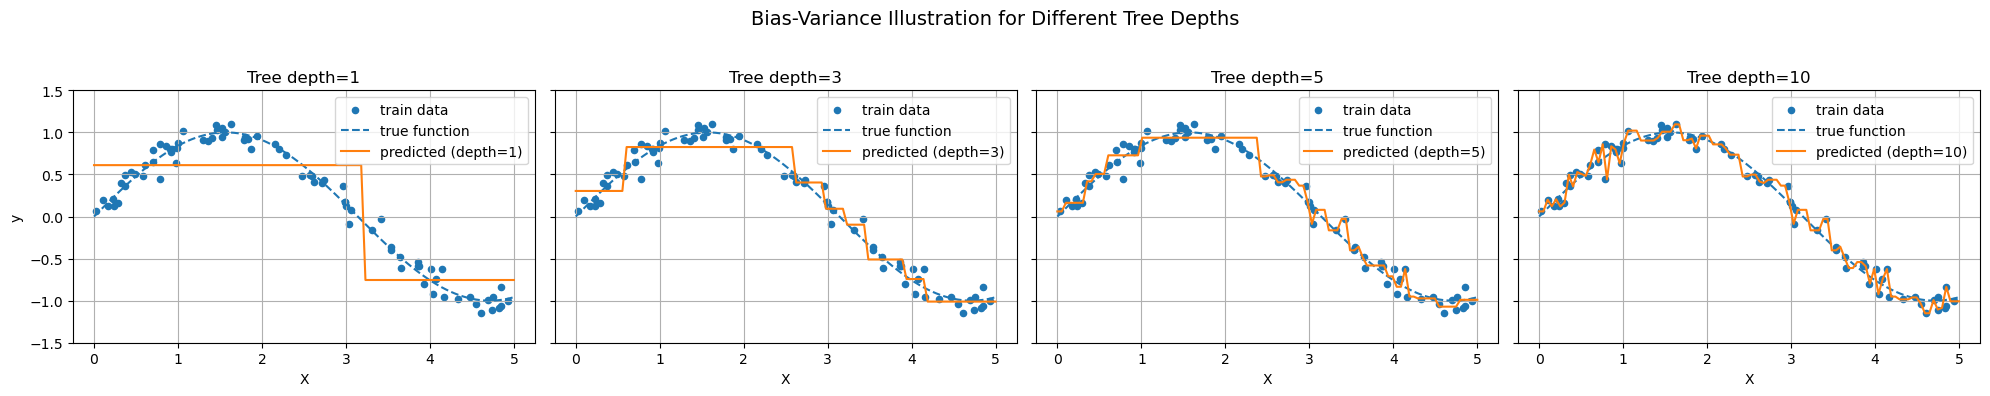

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Dane 
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Dane testowe
X_test = np.linspace(0, 5, 100).reshape(-1, 1)
y_test_true = np.sin(X_test).ravel()

# Modele o różnych głębokościach (kontrola bias-wariancja)
depths = [1, 3, 5, 10]
predictions = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X, y)
    y_pred = model.predict(X_test)
    predictions.append((depth, y_pred))

# Wspólny wykres
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

for ax, (depth, y_pred) in zip(axes, predictions):
    ax.scatter(X, y, s=20, label="train data")
    ax.plot(X_test, y_test_true, label="true function", linestyle="--")
    ax.plot(X_test, y_pred, label=f"predicted (depth={depth})")
    ax.set_title(f"Tree depth={depth}")
    ax.set_xlabel("X")
    ax.grid(True)
    ax.set_ylim(-1.5, 1.5)
    ax.legend(loc="upper right")

axes[0].set_ylabel("y")
fig.suptitle("Bias-Variance Illustration for Different Tree Depths", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Powyżej widać ilustrację wpływu **głębokości drzewa decyzyjnego** na **bias i wariancję**:

- **Depth = 1**: bardzo uproszczony model, który mocno odbiega od rzeczywistej funkcji (`sin(x)`) → **wysoki bias, niski wariancja**.
- **Depth = 3**: już lepiej odwzorowuje kształt, ale nadal upraszcza.
- **Depth = 5**: coraz lepsze dopasowanie → **niższy bias**, umiarkowana wariancja.
- **Depth = 10**: model mocno dopasowany do danych uczących → **niski bias, wysoka wariancja** (widoczna "nerwowość" linii).

To klasyczna ilustracja zasady:
- mała złożoność → duży **bias**, mała **wariancja**,
- duża złożoność → mały **bias**, duża **wariancja**.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Model 1: regresja liniowa (wysoki bias, niska wariancja)
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X_test)

# Model 2: Gradient Boosting (niski bias, umiarkowana wariancja)
boost = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
boost.fit(X, y)
y_pred_boost = boost.predict(X_test)

# Wykres porównawczy
plt.figure(figsize=(6, 4))
plt.scatter(X, y, s=20, label="train data")
plt.plot(X_test, y_test_true, label="true function", linestyle="--")
plt.plot(X_test, y_pred_lin, label="Linear Regression (high bias)", linewidth=2)
plt.plot(X_test, y_pred_boost, label="Gradient Boosting (low bias)", linewidth=2)
plt.title("Bias Comparison: Linear Regression vs Gradient Boosting")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.ylim(-1.5, 1.5)
plt.show()

Na wykresie widać porównanie:

- **Regresji liniowej** (kolor pomarańczowy) – model z **wysokim biasem**: przewiduje prostą linię, która **nie odwzorowuje nieliniowej zależności** `sin(x)` → underfitting.
- **Gradient Boosting** (kolor zielony) – model z **niskim biasem**: dobrze dopasowuje się do kształtu danych, uchwytuje **nieliniowość** → lepsze odwzorowanie rzeczywistej funkcji.

To pokazuje, dlaczego **redukcja biasu** (np. przez boosting) może znacznie poprawić jakość modelu, gdy dane mają **złożoną strukturę**.  